# Machine Learning detecting financial statement fraud

## Code mô hình

Kích thước dữ liệu: (788, 10)

5 dòng đầu:
  Mã CK  Manipulate  EPS change     Ln(MC)  Leverage  Exchange  Audit  \
0   AAA           1    0.003112  28.763291     23.51         1      1   
1   AAH           0   -1.188119  26.774036      6.34         0      0   
2   AAT           1   -4.576271  26.155877     29.52         1      0   
3   AAV           1    0.475771  26.797743     26.62         1      0   
4   ABC           0    0.544928  26.145206     19.90         0      0   

   Opinion  Beta  Equity change  
0        1  0.95          -2.52  
1        1  1.74          -0.19  
2        0  0.81           5.40  
3        1  0.52          -2.95  
4        1  1.73           2.21  

Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 788 entries, 0 to 787
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Mã CK          788 non-null    object 
 1   Manipulate     788 non-null    int64  
 2   EPS chan

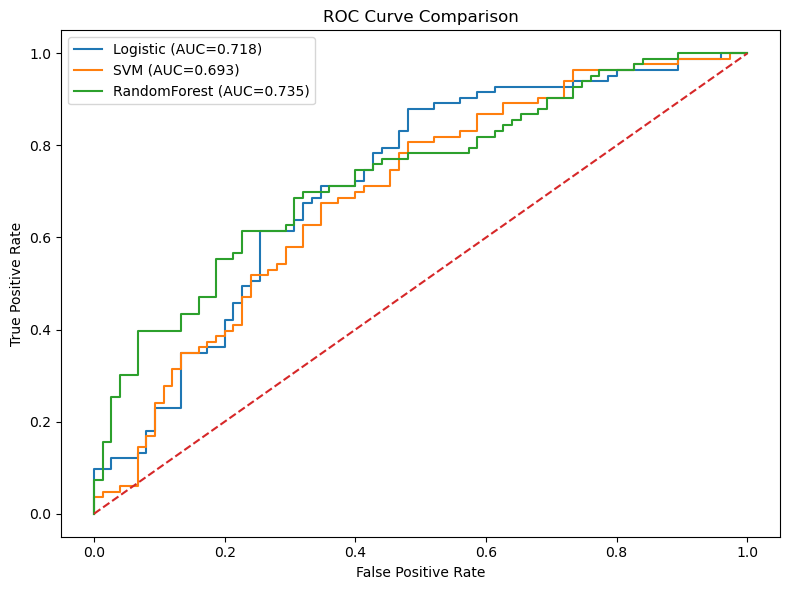

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    silhouette_score
)

# =========================================================
# 1. ĐỌC DỮ LIỆU
# =========================================================
file_path = "Fraud.xlsx"
df = pd.read_excel(file_path)

print("Kích thước dữ liệu:", df.shape)
print("\n5 dòng đầu:")
print(df.head())

print("\nThông tin dữ liệu:")
print(df.info())

print("\nPhân bố biến mục tiêu:")
print(df["Manipulate"].value_counts())
print(df["Manipulate"].value_counts(normalize=True))

# =========================================================
# 2. CHỌN BIẾN
# =========================================================
target_col = "Manipulate"
id_col = "Mã CK"

feature_cols = [col for col in df.columns if col not in [target_col, id_col]]

X = df[feature_cols].copy()
y = df[target_col].copy()

# Nếu sau này có cột object thì giữ phần này
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [col for col in X.columns if col not in numeric_features]

print("\nNumeric features:", numeric_features)
print("Categorical features:", categorical_features)

# =========================================================
# 3. TRAIN / TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, df[id_col],
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTrain size:", X_train.shape)
print("Test size:", X_test.shape)

# =========================================================
# 4. PREPROCESS
# =========================================================
numeric_transformer_scale = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_transformer_noscale = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

# Cho Logistic và SVM
preprocessor_scale = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_scale, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

# Cho Random Forest và KMeans có thể dùng scaler hoặc không
preprocessor_rf = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_noscale, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

# Riêng KMeans nên scale
preprocessor_cluster = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_scale, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

# =========================================================
# 5. HÀM ĐÁNH GIÁ
# =========================================================
def evaluate_model(model_name, model, X_test, y_test, threshold=0.5):
    # lấy xác suất lớp 1
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    print(f"\n{'='*60}")
    print(f"MODEL: {model_name}")
    print(f"Threshold: {threshold}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {pre:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4, zero_division=0))

    result_df = pd.DataFrame({
        "Actual": y_test.values,
        "Pred_Prob": y_prob,
        "Pred_Label": y_pred
    })

    return result_df, {
        "model": model_name,
        "threshold": threshold,
        "accuracy": acc,
        "precision": pre,
        "recall": rec,
        "f1": f1,
        "auc": auc
    }

def find_best_threshold(y_true, y_prob, metric="f1"):
    thresholds = np.arange(0.1, 0.91, 0.01)
    best_threshold = 0.5
    best_score = -1

    for th in thresholds:
        y_pred = (y_prob >= th).astype(int)

        if metric == "f1":
            score = f1_score(y_true, y_pred, zero_division=0)
        elif metric == "recall":
            score = recall_score(y_true, y_pred, zero_division=0)
        elif metric == "precision":
            score = precision_score(y_true, y_pred, zero_division=0)
        else:
            score = f1_score(y_true, y_pred, zero_division=0)

        if score > best_score:
            best_score = score
            best_threshold = th

    return best_threshold, best_score

# =========================================================
# 6. MODEL 1 - LOGISTIC REGRESSION
# =========================================================
pipe_logit = ImbPipeline(steps=[
    ("preprocess", preprocessor_scale),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])

param_grid_logit = {
    "model__C": [0.01, 0.1, 1, 5, 10]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_logit = GridSearchCV(
    estimator=pipe_logit,
    param_grid=param_grid_logit,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid_logit.fit(X_train, y_train)

print("\nBest Logistic params:", grid_logit.best_params_)
best_logit = grid_logit.best_estimator_

# tìm threshold tốt trên tập train bằng predict xác suất cross-val
logit_train_prob = cross_val_predict(
    best_logit, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

best_th_logit, best_score_logit = find_best_threshold(y_train, logit_train_prob, metric="f1")
print("Best threshold Logistic:", best_th_logit, "| Best F1:", round(best_score_logit, 4))

logit_result_df, logit_metrics = evaluate_model(
    "Logistic Regression", best_logit, X_test, y_test, threshold=best_th_logit
)

# =========================================================
# 7. MODEL 2 - SVM
# =========================================================
pipe_svm = ImbPipeline(steps=[
    ("preprocess", preprocessor_scale),
    ("smote", SMOTE(random_state=42)),
    ("model", SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ))
])

param_grid_svm = {
    "model__C": [0.1, 1, 5, 10],
    "model__kernel": ["rbf", "linear"],
    "model__gamma": ["scale", "auto"]
}

grid_svm = GridSearchCV(
    estimator=pipe_svm,
    param_grid=param_grid_svm,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

print("\nBest SVM params:", grid_svm.best_params_)
best_svm = grid_svm.best_estimator_

svm_train_prob = cross_val_predict(
    best_svm, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

best_th_svm, best_score_svm = find_best_threshold(y_train, svm_train_prob, metric="f1")
print("Best threshold SVM:", best_th_svm, "| Best F1:", round(best_score_svm, 4))

svm_result_df, svm_metrics = evaluate_model(
    "SVM", best_svm, X_test, y_test, threshold=best_th_svm
)

# =========================================================
# 8. MODEL 3 - RANDOM FOREST
# =========================================================
pipe_rf = ImbPipeline(steps=[
    ("preprocess", preprocessor_rf),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

param_grid_rf = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 5, 10, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("\nBest RandomForest params:", grid_rf.best_params_)
best_rf = grid_rf.best_estimator_

rf_train_prob = cross_val_predict(
    best_rf, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

best_th_rf, best_score_rf = find_best_threshold(y_train, rf_train_prob, metric="f1")
print("Best threshold RF:", best_th_rf, "| Best F1:", round(best_score_rf, 4))

rf_result_df, rf_metrics = evaluate_model(
    "Random Forest", best_rf, X_test, y_test, threshold=best_th_rf
)


# =========================================================
# 9. SO SÁNH 3 MODEL
# =========================================================
metrics_df = pd.DataFrame([logit_metrics, svm_metrics, rf_metrics])
print("\nBảng so sánh mô hình:")
print(metrics_df.sort_values(by=["f1", "auc"], ascending=False))

best_model_name = metrics_df.sort_values(by=["f1", "auc"], ascending=False).iloc[0]["model"]
print("\nMô hình tốt nhất theo F1 rồi đến AUC:", best_model_name)

# =========================================================
# 10. FEATURE IMPORTANCE (cho Random Forest)
# =========================================================
rf_model = best_rf.named_steps["model"]

# sau preprocess_rf, thứ tự feature gần như là numeric_features + categorical_features
all_processed_features = numeric_features + categorical_features
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": all_processed_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance - Random Forest:")
print(importance_df)

# =========================================================
# 11. CLUSTERING - KMEANS
# =========================================================
# KMeans không dự đoán xác suất gian lận thật sự
# Ta dùng để phân nhóm doanh nghiệp rồi tính tỷ lệ gian lận trong từng cluster

X_train_cluster = preprocessor_cluster.fit_transform(X_train)
X_test_cluster = preprocessor_cluster.transform(X_test)

# tìm số cluster phù hợp bằng silhouette
best_k = 2
best_sil = -1

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    cluster_labels = km.fit_predict(X_train_cluster)
    sil = silhouette_score(X_train_cluster, cluster_labels)
    print(f"K={k} | Silhouette={sil:.4f}")
    if sil > best_sil:
        best_sil = sil
        best_k = k

print("\nBest K for clustering:", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
train_clusters = kmeans.fit_predict(X_train_cluster)
test_clusters = kmeans.predict(X_test_cluster)

# Tính risk score theo cluster trên train
cluster_risk = pd.DataFrame({
    "cluster": train_clusters,
    "fraud": y_train.values
}).groupby("cluster")["fraud"].mean().to_dict()

print("\nFraud rate theo cluster:")
print(cluster_risk)

cluster_test_risk = pd.Series(test_clusters).map(cluster_risk).values

cluster_result_df = pd.DataFrame({
    "Mã CK": id_test.values,
    "Actual": y_test.values,
    "Cluster": test_clusters,
    "Cluster_Risk_Score": cluster_test_risk
})

print("\nKết quả cluster mẫu:")
print(cluster_result_df.head())

# =========================================================
# 12. XUẤT FILE KẾT QUẢ
# =========================================================
test_result = pd.DataFrame({
    "Mã CK": id_test.values,
    "Actual": y_test.values,

    "Logit_Prob": best_logit.predict_proba(X_test)[:, 1],
    "Logit_Pred": (best_logit.predict_proba(X_test)[:, 1] >= best_th_logit).astype(int),

    "SVM_Prob": best_svm.predict_proba(X_test)[:, 1],
    "SVM_Pred": (best_svm.predict_proba(X_test)[:, 1] >= best_th_svm).astype(int),

    "RF_Prob": best_rf.predict_proba(X_test)[:, 1],
    "RF_Pred": (best_rf.predict_proba(X_test)[:, 1] >= best_th_rf).astype(int),

    "Cluster": test_clusters,
    "Cluster_Risk_Score": cluster_test_risk
})

# Xếp hạng rủi ro theo RF
test_result = test_result.sort_values(by="RF_Prob", ascending=False)

test_result.to_excel("fraud_prediction_results.xlsx", index=False)
metrics_df.to_excel("fraud_model_metrics.xlsx", index=False)
importance_df.to_excel("rf_feature_importance.xlsx", index=False)

joblib.dump(best_logit, "best_logit_model.pkl")
joblib.dump(best_svm, "best_svm_model.pkl")
joblib.dump(best_rf, "best_rf_model.pkl")
joblib.dump(kmeans, "kmeans_cluster.pkl")

print("\nĐã lưu:")
print("- fraud_prediction_results.xlsx")
print("- fraud_model_metrics.xlsx")
print("- rf_feature_importance.xlsx")
print("- best_logit_model.pkl")
print("- best_svm_model.pkl")
print("- best_rf_model.pkl")
print("- kmeans_cluster.pkl")

# =========================================================
# 13. VẼ ROC CURVE
# =========================================================
plt.figure(figsize=(8, 6))

for model_name, model in [
    ("Logistic", best_logit),
    ("SVM", best_svm),
    ("RandomForest", best_rf)
]:
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

## Vẽ ROC Curve 4 mô hình

In [9]:
# 13. VẼ ROC CURVE
# =========================================================
plt.figure(figsize=(8, 6))

for model_name, model in [
    ("Logistic", best_logit),
    ("SVM", best_svm),
    ("RandomForest", best_rf),
    ("Hist Gradient Boosting", hgb_model)
]:
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'hgb_model' is not defined

<Figure size 800x600 with 0 Axes>

##

In [ ]:
from sklearn.model_selection import cross_validate

# =========================================================
# CROSS VALIDATION
# =========================================================
print("\n" + "="*60)
print("CROSS VALIDATION (5-FOLD)")
print("="*60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

models = {
    "Logistic Regression": best_logit,
    "SVM": best_svm,
    "Random Forest": best_rf
}

cv_results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=True
    )

    result = {
        "Model": name,

        "Train Accuracy": scores["train_accuracy"].mean(),
        "Test Accuracy": scores["test_accuracy"].mean(),

        "Train Precision": scores["train_precision"].mean(),
        "Test Precision": scores["test_precision"].mean(),

        "Train Recall": scores["train_recall"].mean(),
        "Test Recall": scores["test_recall"].mean(),

        "Train F1": scores["train_f1"].mean(),
        "Test F1": scores["test_f1"].mean(),

        "Train AUC": scores["train_roc_auc"].mean(),
        "Test AUC": scores["test_roc_auc"].mean(),

        # độ ổn định
        "F1 Std": scores["test_f1"].std(),
        "AUC Std": scores["test_roc_auc"].std()
    }

    cv_results.append(result)

cv_df = pd.DataFrame(cv_results).round(4)

print("\nKết quả Cross Validation:")
print(cv_df.sort_values(by="Test F1", ascending=False))

# Xuất file
cv_df.to_excel("cross_validation_results.xlsx", index=False)
print("\nĐã lưu: cross_validation_results.xlsx")


CROSS VALIDATION (5-FOLD)

Kết quả Cross Validation:
                 Model  Train Accuracy  Test Accuracy  Train Precision  \
2        Random Forest          0.9254         0.6603           0.9426   
1                  SVM          0.6750         0.6540           0.6968   
0  Logistic Regression          0.6655         0.6508           0.7037   

   Test Precision  Train Recall  Test Recall  Train F1  Test F1  Train AUC  \
2          0.6773        0.9142       0.6835    0.9281   0.6798     0.9848   
1          0.6728        0.6784       0.6686    0.6871   0.6703     0.7370   
0          0.6889        0.6310       0.6145    0.6653   0.6489     0.7127   

   Test AUC  F1 Std  AUC Std  
2    0.7080  0.0561   0.0597  
1    0.7077  0.0415   0.0441  
0    0.6996  0.0468   0.0428  

Đã lưu: cross_validation_results.xlsx


In [ ]:
sample = X_test.iloc[0:1]

prob = best_logit.predict_proba(sample)[0][1]
print("Xác suất gian lận:", prob)

Xác suất gian lận: 0.4264380470282604


In [ ]:
model = best_logit.named_steps["model"]

coefficients = model.coef_[0]
features = numeric_features + categorical_features

coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", ascending=False)

print(coef_df)

         Feature  Coefficient
2       Leverage     0.523988
6           Beta     0.363686
7  Equity change     0.063232
0     EPS change    -0.088506
3       Exchange    -0.088685
4          Audit    -0.154121
1         Ln(MC)    -0.185990
5        Opinion    -0.276218


In [ ]:
import pandas as pd

# Chọn các biến số (bỏ Mã CK)
df_corr = df.drop(columns=["Mã CK"])

# Tính ma trận tương quan
corr_matrix = df_corr.corr()

print(corr_matrix)

               Manipulate  EPS change    Ln(MC)  Leverage  Exchange     Audit  \
Manipulate       1.000000   -0.034028 -0.136544  0.256256 -0.080486 -0.130804   
EPS change      -0.034028    1.000000  0.049627  0.012592  0.042386  0.021715   
Ln(MC)          -0.136544    0.049627  1.000000 -0.083853  0.169389  0.472560   
Leverage         0.256256    0.012592 -0.083853  1.000000 -0.046558 -0.022224   
Exchange        -0.080486    0.042386  0.169389 -0.046558  1.000000  0.142909   
Audit           -0.130804    0.021715  0.472560 -0.022224  0.142909  1.000000   
Opinion         -0.187532    0.116305  0.201881 -0.031364  0.316114  0.199403   
Beta             0.113252    0.040878  0.302413  0.022261 -0.053349  0.128277   
Equity change   -0.038361    0.017641  0.148813 -0.070295  0.158938  0.039291   

                Opinion      Beta  Equity change  
Manipulate    -0.187532  0.113252      -0.038361  
EPS change     0.116305  0.040878       0.017641  
Ln(MC)         0.201881  0.302413   

In [ ]:
import pandas as pd

# Đọc dữ liệu
df = pd.read_excel("Fraud.xlsx")

# Chọn các biến cần thống kê mô tả
cols = [
    "Manipulate",
    "EPS change",
    "Ln(MC)",
    "Leverage",
    "Exchange",
    "Audit",
    "Opinion",
    "Beta",
    "Equity change"
]

desc = df[cols].describe().T
desc["median"] = df[cols].median()
desc["skew"] = df[cols].skew()
desc["kurtosis"] = df[cols].kurt()

# Sắp xếp lại cột cho đẹp
desc = desc[[
    "count", "mean", "std", "min", "25%", "50%", "75%", "max", "median", "skew", "kurtosis"
]]

print(desc)

               count       mean        std         min        25%        50%  \
Manipulate     788.0   0.526650   0.499606    0.000000   0.000000   1.000000   
EPS change     788.0  -0.160448  21.450270 -516.666667  -0.288973   0.080525   
Ln(MC)         788.0  27.334075   1.887150   22.534828  25.943845  27.130842   
Leverage       788.0  25.166434  17.397534    0.050000  11.450000  22.700000   
Exchange       788.0   0.631980   0.482573    0.000000   0.000000   1.000000   
Audit          788.0   0.246193   0.431066    0.000000   0.000000   0.000000   
Opinion        788.0   0.865482   0.341424    0.000000   1.000000   1.000000   
Beta           788.0   0.573439   0.563283   -1.370000   0.180000   0.500000   
Equity change  788.0   7.035381  52.607626 -316.200000   0.687500   4.365000   

                     75%         max     median       skew    kurtosis  
Manipulate      1.000000    1.000000   1.000000  -0.106954   -1.993627  
EPS change      0.551365   80.647059   0.080525 -19.1

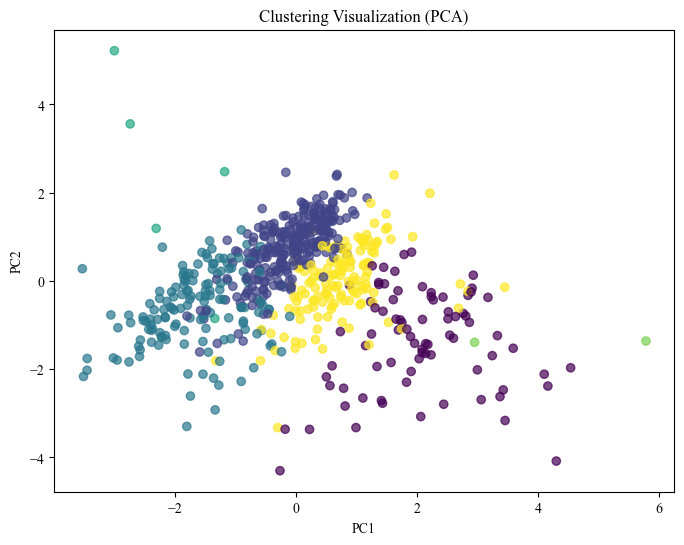

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 👉 Set font Times New Roman
plt.rcParams["font.family"] = "Times New Roman"

# giảm chiều về 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_cluster)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=train_clusters,
    alpha=0.7
)

plt.title("Clustering Visualization (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [ ]:
# =========================================================
# MODEL MỚI - HIST GRADIENT BOOSTING CÓ THRESHOLD TỐI ƯU
# =========================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# =========================================================
# 1. Đọc dữ liệu
# =========================================================
file_path = "Fraud.xlsx"
df = pd.read_excel(file_path)

target_col = "Manipulate"
id_col = "Mã CK"

feature_cols = [
    "EPS change",
    "Ln(MC)",
    "Leverage",
    "Exchange",
    "Audit",
    "Opinion",
    "Beta",
    "Equity change"
]

X = df[feature_cols].copy()
y = df[target_col].copy()

# =========================================================
# 2. Train-test split
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================================================
# 3. Hàm tìm threshold tối ưu
# =========================================================
def find_best_threshold(y_true, y_prob, metric="f1"):
    thresholds = np.arange(0.10, 0.91, 0.01)
    best_threshold = 0.5
    best_score = -1

    for th in thresholds:
        y_pred = (y_prob >= th).astype(int)

        if metric == "f1":
            score = f1_score(y_true, y_pred, zero_division=0)
        elif metric == "recall":
            score = recall_score(y_true, y_pred, zero_division=0)
        elif metric == "precision":
            score = precision_score(y_true, y_pred, zero_division=0)
        else:
            score = f1_score(y_true, y_pred, zero_division=0)

        if score > best_score:
            best_score = score
            best_threshold = th

    return best_threshold, best_score

# =========================================================
# 4. Khởi tạo model
# =========================================================
hgb_model = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.03,
    max_depth=3,
    random_state=42
)

# =========================================================
# 5. Train model
# =========================================================
hgb_model.fit(X_train, y_train)

# =========================================================
# 6. Tìm threshold tối ưu trên tập train bằng cross_val_predict
# =========================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_prob_cv = cross_val_predict(
    hgb_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

best_th_hgb, best_f1_hgb = find_best_threshold(y_train, train_prob_cv, metric="f1")

print("Best Threshold HGB:", round(best_th_hgb, 2))
print("Best CV-F1 on train:", round(best_f1_hgb, 4))

# =========================================================
# 7. Predict trên test với threshold tối ưu
# =========================================================
y_prob = hgb_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= best_th_hgb).astype(int)

# =========================================================
# 8. Evaluate
# =========================================================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)

print("\n===== HIST GRADIENT BOOSTING (OPTIMAL THRESHOLD) =====")
print("Threshold :", round(best_th_hgb, 2))
print("Accuracy  :", round(accuracy, 4))
print("Precision :", round(precision, 4))
print("Recall    :", round(recall, 4))
print("F1-score  :", round(f1, 4))
print("AUC       :", round(auc, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

# =========================================================
# 9. Xuất kết quả dự đoán nếu cần
# =========================================================
hgb_result = pd.DataFrame({
    "Actual": y_test.values,
    "Pred_Prob": y_prob,
    "Pred_Label": y_pred
})

hgb_result.to_excel("hgb_threshold_results.xlsx", index=False)
print("\nĐã lưu: hgb_threshold_results.xlsx")

Best Threshold HGB: 0.36
Best CV-F1 on train: 0.6904

===== HIST GRADIENT BOOSTING (OPTIMAL THRESHOLD) =====
Threshold : 0.36
Accuracy  : 0.6835
Precision : 0.6435
Recall    : 0.8916
F1-score  : 0.7475
AUC       : 0.7613

Confusion Matrix:
[[34 41]
 [ 9 74]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7907    0.4533    0.5763        75
           1     0.6435    0.8916    0.7475        83

    accuracy                         0.6835       158
   macro avg     0.7171    0.6724    0.6619       158
weighted avg     0.7134    0.6835    0.6662       158


Đã lưu: hgb_threshold_results.xlsx


In [ ]:
import pandas as pd
import numpy as np

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_validate

# =========================================================
# HÀM ĐÁNH GIÁ OVERFIT
# =========================================================
def evaluate_overfit(model_name, model, X_train, y_train, X_test, y_test):
    # ----- Train -----
    y_train_pred = model.predict(X_train)
    y_train_prob = model.predict_proba(X_train)[:, 1]

    train_acc = accuracy_score(y_train, y_train_pred)
    train_pre = precision_score(y_train, y_train_pred, zero_division=0)
    train_rec = recall_score(y_train, y_train_pred, zero_division=0)
    train_f1 = f1_score(y_train, y_train_pred, zero_division=0)
    train_auc = roc_auc_score(y_train, y_train_prob)

    # ----- Test -----
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]

    test_acc = accuracy_score(y_test, y_test_pred)
    test_pre = precision_score(y_test, y_test_pred, zero_division=0)
    test_rec = recall_score(y_test, y_test_pred, zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
    test_auc = roc_auc_score(y_test, y_test_prob)

    # ----- Gaps -----
    acc_gap = train_acc - test_acc
    f1_gap = train_f1 - test_f1
    auc_gap = train_auc - test_auc

    # Quy tắc kết luận đơn giản
    if f1_gap > 0.15 or auc_gap > 0.15:
        overfit_level = "Overfit rõ rệt"
    elif f1_gap > 0.07 or auc_gap > 0.07:
        overfit_level = "Overfit nhẹ đến trung bình"
    else:
        overfit_level = "Khá ổn định"

    return {
        "Model": model_name,

        "Train Accuracy": round(train_acc, 4),
        "Test Accuracy": round(test_acc, 4),
        "Accuracy Gap": round(acc_gap, 4),

        "Train Precision": round(train_pre, 4),
        "Test Precision": round(test_pre, 4),

        "Train Recall": round(train_rec, 4),
        "Test Recall": round(test_rec, 4),

        "Train F1": round(train_f1, 4),
        "Test F1": round(test_f1, 4),
        "F1 Gap": round(f1_gap, 4),

        "Train AUC": round(train_auc, 4),
        "Test AUC": round(test_auc, 4),
        "AUC Gap": round(auc_gap, 4),

        "Kết luận": overfit_level
    }

# =========================================================
# CHẠY CHO CÁC MODEL
# =========================================================
overfit_results = []

overfit_results.append(
    evaluate_overfit("Logistic Regression", best_logit, X_train, y_train, X_test, y_test)
)

overfit_results.append(
    evaluate_overfit("SVM", best_svm, X_train, y_train, X_test, y_test)
)

overfit_results.append(
    evaluate_overfit("Random Forest", best_rf, X_train, y_train, X_test, y_test)
)

# Nếu bạn có model HGB:
overfit_results.append(
    evaluate_overfit("HistGradientBoosting", hgb_model, X_train, y_train, X_test, y_test)
)

overfit_df = pd.DataFrame(overfit_results)
print(overfit_df)

# Xuất file nếu cần
overfit_df.to_excel("overfit_test_results.xlsx", index=False)
print("\nĐã lưu: overfit_test_results.xlsx")

NameError: name 'best_logit' is not defined

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

# đọc file
df = pd.read_excel(r"C:\Users\manhphi2811\OneDrive - National Economics University\KLTN\Trọng số.xlsx")

X = df[['Mscore', 'Fscore', 'Zscore']]

# chuẩn hóa
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=1)
pca.fit(X_scaled)

print(pca.components_)

[[-0.65484963  0.72509824 -0.21308334]]


In [ ]:
df.head()

,Mã CK,Mscore,Fscore,Zscore
0,AAA,-2.038957,-0.413611,1.635381
1,AAH,-2.125057,-0.377519,1.864724
2,AAT,-2.296601,0.337856,1.227915
3,AAV,3.907509,-0.006331,0.853837
4,ABC,-2.814996,-0.183624,2.960043
